<a href="https://colab.research.google.com/github/pradeep-dani/pd-mt-iiitdh-colab/blob/main/ds-lab-assignments/assigments/DS_Lab_6_22_11_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1 — Univariate Analysis
(Moderate Coding)

You are given the following dataset (CSV):

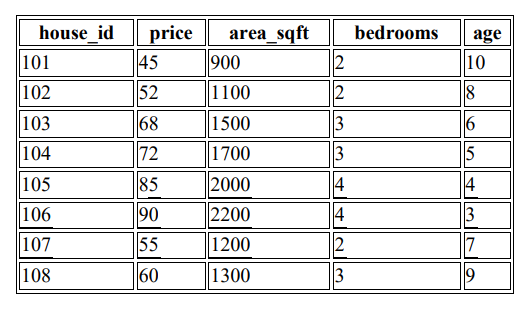



Tasks

Write Python code using NumPy/pandas to:
1. Load the dataset into a DataFrame.
2. Compute the following for the price column:
o Mean
o Median
o Standard Deviation
o 25th and 75th Percentile
3. Plot:
o Histogram of price
o Boxplot of price
4. Identify outliers using the IQR rule.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the dataset into a DataFrame.
# The data is defined as a string to simulate reading from a CSV file in a Colab notebook.
data = """
house_id,price,area_sqft,bedrooms,age
101,45,900,2,10
102,52,1100,2,8
103,68,1500,3,6
104,72,1700,3,5
105,85,2000,4,4
106,90,2200,4,3
107,55,1200,2,7
108,60,1300,3,9
109,250,5000,5,1
"""

# Use io.StringIO to treat the string as a file and load it into a DataFrame
df = pd.read_csv(io.StringIO(data))

print("1. Loaded Dataset (DataFrame Head)\n\n")
print(df.head())

1. Loaded Dataset (DataFrame Head)


   house_id  price  area_sqft  bedrooms  age
0       101     45        900         2   10
1       102     52       1100         2    8
2       103     68       1500         3    6
3       104     72       1700         3    5
4       105     85       2000         4    4


In [7]:
# 2. Compute descriptive statistics for the 'price' column.
print("\n\n")
price_series = df['price']

# Use the .describe() method for a quick summary, then extract specific values
stats = price_series.describe()

mean_price = stats['mean']
median_price = stats['50%']
std_dev_price = stats['std']
p25 = stats['25%']
p75 = stats['75%']

print("2. Price Statistics\n")
print(f"2.a) Mean Price:             {mean_price:.2f}")
print(f"2.b) Median Price:           {median_price:.2f}")
print(f"2.c) Standard Deviation:     {std_dev_price:.2f}")
print(f"2.d) 25th Percentile (Q1):   {p25:.2f}")
print(f"2.e) 75th Percentile (Q3):   {p75:.2f}")





2. Price Statistics

2.a) Mean Price:             86.33
2.b) Median Price:           68.00
2.c) Standard Deviation:     63.15
2.d) 25th Percentile (Q1):   55.00
2.e) 75th Percentile (Q3):   85.00


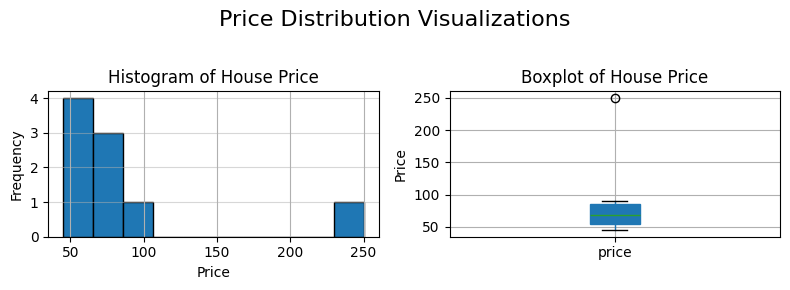

In [10]:
# 3. Plot: Histogram and Boxplot of price
plt.figure(figsize=(8, 3))

# Plot 3a: Histogram of price
plt.subplot(1, 2, 1)
price_series.hist(bins=10, edgecolor='black')
plt.title('Histogram of House Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)

# Plot 3b: Boxplot of price
plt.subplot(1, 2, 2)
df.boxplot(column=['price'], vert=True, patch_artist=True)
plt.title('Boxplot of House Price')
plt.ylabel('Price')
plt.suptitle('Price Distribution Visualizations', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()


In [13]:
#4. Identify outliers using the IQR rule.
# The Interquartile Range (IQR) rule identifies an outlier if a data point
# falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

# Calculate IQR
IQR = p75 - p25

# Calculate the bounds
lower_bound = p25 - (1.5 * IQR)
upper_bound = p75 + (1.5 * IQR)

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print("4. Outlier Detection (IQR Rule)")
print(f"Q1 (25th Percentile)      : {p25:.2f}")
print(f"Q3 (75th Percentile)      : {p75:.2f}")
print(f"IQR (Q3 - Q1)             : {IQR:.2f}")
print(f"Lower Bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound:.2f}")

if not outliers.empty:
    print("\nOutliers Found (Houses with price outside the [Lower Bound, Upper Bound] range):")
    print(outliers)
else:
    print("\nNo outliers found in the 'price' column based on the 1.5 * IQR rule.")

4. Outlier Detection (IQR Rule)
Q1 (25th Percentile)      : 55.00
Q3 (75th Percentile)      : 85.00
IQR (Q3 - Q1)             : 30.00
Lower Bound (Q1 - 1.5*IQR): 10.00
Upper Bound (Q3 + 1.5*IQR): 130.00

Outliers Found (Houses with price outside the [Lower Bound, Upper Bound] range):
   house_id  price  area_sqft  bedrooms  age
8       109    250       5000         5    1


Problem 2 — Multivariate Analysis
(Moderate Coding)
Use the same dataset as above.
Tasks
1. Compute the correlation matrix among:

    o price

    o area_sqft

    o bedrooms

    o age

2. Create:

    o A heatmap of the correlation matrix

    o A scatterplot (area_sqft vs price)

    o A pairplot of all numeric variables

3. Interpret:

    o Which variable has the strongest positive correlation with price?

    o Does age appear to reduce house prices?



In [15]:
# 1. Compute the correlation matrix among the specified variables.
# The .corr() method calculates Pearson correlation coefficients by default.
numeric_vars = ['price', 'area_sqft', 'bedrooms', 'age']
correlation_matrix = df[numeric_vars].corr()

print("\n 1. Correlation Matrix (Numeric Variables) \n")
# Display the matrix, rounded to 2 decimal places for clarity
print(correlation_matrix.round(2))


 1. Correlation Matrix (Numeric Variables) 

           price  area_sqft  bedrooms   age
price       1.00       0.99      0.82 -0.78
area_sqft   0.99       1.00      0.87 -0.84
bedrooms    0.82       0.87      1.00 -0.88
age        -0.78      -0.84     -0.88  1.00


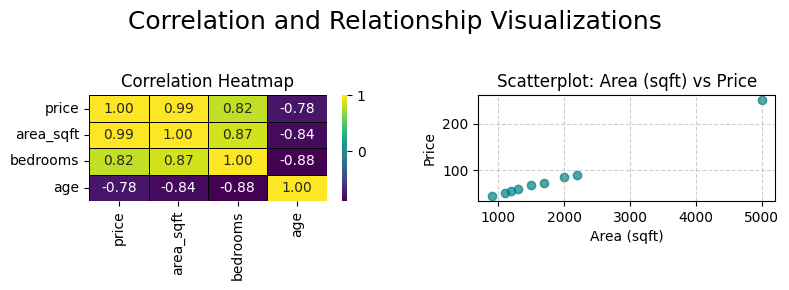




--- Generating Pairplot (All-in-one scatter/histogram visualization) ---


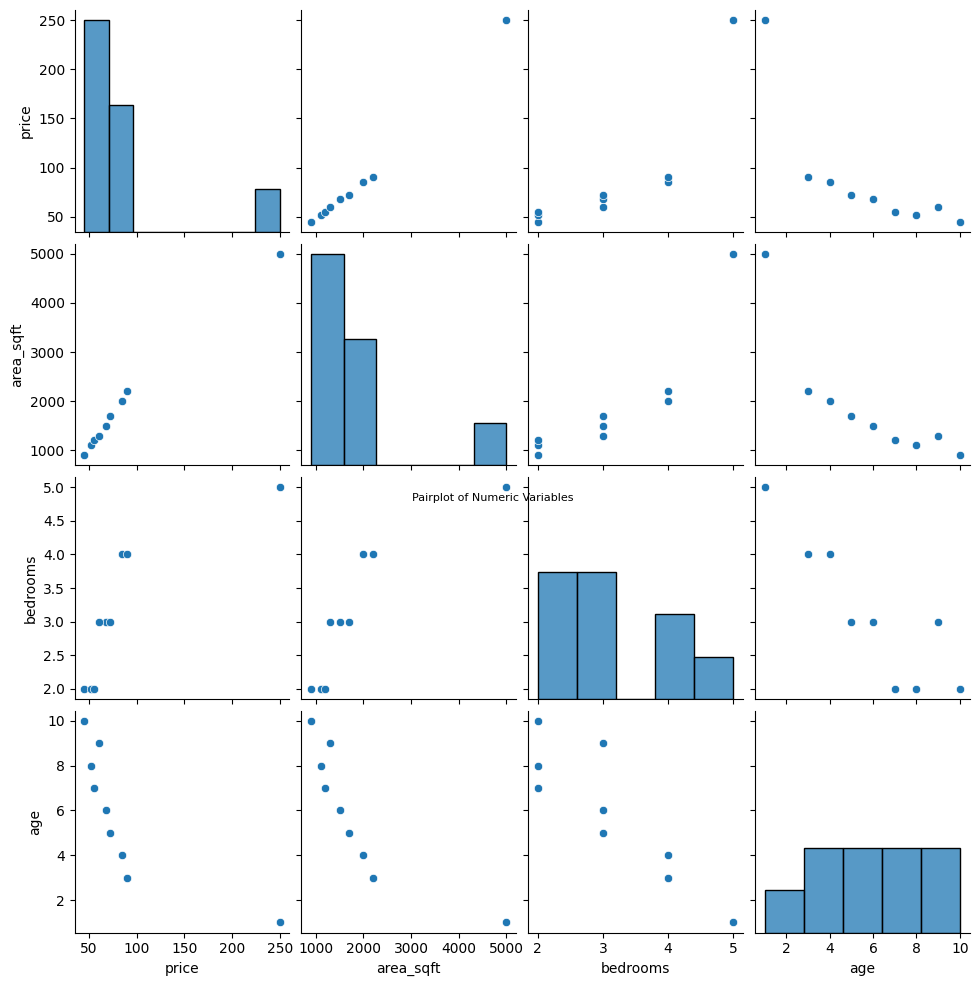

In [20]:
import seaborn as sns # Added for advanced statistical plotting (Heatmap and Pairplot)
import io

# 2. Create visualizations.
# Set up a figure for the Heatmap and Scatterplot side-by-side
plt.figure(figsize=(8, 3))

# Plot 2a: Heatmap of the correlation matrix
plt.subplot(1, 2, 1)
sns.heatmap(
    correlation_matrix,
    annot=True,              # Display correlation values on the map
    cmap='viridis',          # Choose a color palette
    fmt=".2f",               # Format the numbers to two decimal places
    linewidths=.5,           # Add lines between cells
    linecolor='black'
)
plt.title('Correlation Heatmap')

# Plot 2b: Scatterplot (area_sqft vs price)
plt.subplot(1, 2, 2)
plt.scatter(df['area_sqft'], df['price'], color='teal', alpha=0.7)
plt.title('Scatterplot: Area (sqft) vs Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Correlation and Relationship Visualizations', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

print("\n\n")

# Plot 2c: Pairplot of all numeric variables
print("--- Generating Pairplot (All-in-one scatter/histogram visualization) ---")
# The Pairplot plots pairwise relationships (scatterplots) and distributions (histograms)
# for all variables in the DataFrame. 'house_id' is excluded as it's an identifier.
sns.pairplot(df.drop(columns=['house_id']))
plt.suptitle('Pairplot of Numeric Variables', y=1.02, fontsize=8)
plt.show()

In [21]:
# 3. Interpretation.
print("3. Interpretation of Correlation Matrix \n\n")

# Find the strongest positive correlation with 'price' (excluding price itself)
price_correlations = correlation_matrix['price'].drop('price')
strongest_positive_corr_var = price_correlations.idxmax()
strongest_positive_corr_val = price_correlations.max()

print("Which variable has the strongest positive correlation with price?")
print(f"Answer: {strongest_positive_corr_var} with a correlation of {strongest_positive_corr_val:.2f}.")
print("This indicates that the size of the house (area) is the primary factor driving the price up.")

age_price_corr = correlation_matrix.loc['price', 'age']
print(f"\nDoes age appear to reduce house prices?")
print(f"Correlation between 'price' and 'age': {age_price_corr:.2f}")

if age_price_corr < -0.5:
    print(f"Answer: Yes. The strong negative correlation ({age_price_corr:.2f}) suggests a significant tendency for older houses to have lower prices.")
elif age_price_corr < 0:
    print(f"Answer: Yes. The moderate negative correlation ({age_price_corr:.2f}) suggests a clear, but not dominating, tendency for house price to decrease as age increases.")
else:
    print(f"Answer: No. While the correlation is slightly positive, its value is close to zero, meaning age is not a significant predictor of price in this dataset.")


3. Interpretation of Correlation Matrix 


Which variable has the strongest positive correlation with price?
Answer: area_sqft with a correlation of 0.99.
This indicates that the size of the house (area) is the primary factor driving the price up.

Does age appear to reduce house prices?
Correlation between 'price' and 'age': -0.78
Answer: Yes. The strong negative correlation (-0.78) suggests a significant tendency for older houses to have lower prices.


Problem 3 — Linear Regression (Moderate
Coding)

Using the same dataset, build a multiple linear regression model predicting:

price ~ area_sqft + bedrooms + age

Tasks

1. Split the dataset into train (70%) and test (30%).

2. Fit a scikit-learn LinearRegression() model.

3. Report:

    o Coefficients

    o Intercept

4. Evaluate model using:

    o MAE

    o MSE

    o RMSE

    o R² score

5. Predict the price for a new house:

    o area = 1800 sq ft

    o bedrooms = 3

    o age = 5 years


In [22]:
import pandas as pd
import numpy as np
import io
# Import necessary scikit-learn modules for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define Features (X) and Target (y)
# Features: area_sqft, bedrooms, age
X = df[['area_sqft', 'bedrooms', 'age']]
# Target: price
y = df['price']

print("Features (X):", X.columns.tolist())
print("Target (y): price")

Features (X): ['area_sqft', 'bedrooms', 'age']
Target (y): price


In [26]:
# 1. Split the dataset into train (70%) and test (30%).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\n  Training set size (70%) : {X_train.shape[0]} rows")
print(f"   Testing set size (30%) : {X_test.shape[0]} rows")


  Training set size (70%) : 6 rows
   Testing set size (30%) : 3 rows


In [27]:
# 2. Fit a scikit-learn LinearRegression() model.
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:

print("3. Model Parameters \n")

# 3. Report Coefficients and Intercept
feature_names = X.columns
coefficients = model.coef_
intercept = model.intercept_

print(f"Intercept (b0): {intercept:.2f}")
print("Coefficients (b1, b2, b3):")
for name, coeff in zip(feature_names, coefficients):
    print(f"  {name}: {coeff:.4f}")

print("\nInterpretation of the model (price = b0 + b1*area + b2*bedrooms + b3*age):")
print(f"  - Holding other variables constant, a 1 unit increase in 'area_sqft' is associated with a ${coefficients[0]:.4f} increase in price.")
print(f"  - A 1 unit increase in 'bedrooms' is associated with a ${coefficients[1]:.4f} increase in price.")
print(f"  - A 1 unit increase in 'age' is associated with a ${coefficients[2]:.4f} decrease in price.")


3. Model Parameters 

Intercept (b0): -30.60
Coefficients (b1, b2, b3):
  area_sqft: 0.0591
  bedrooms: -3.6136
  age: 3.0384

Interpretation of the model (price = b0 + b1*area + b2*bedrooms + b3*age):
  - Holding other variables constant, a 1 unit increase in 'area_sqft' is associated with a $0.0591 increase in price.
  - A 1 unit increase in 'bedrooms' is associated with a $-3.6136 increase in price.
  - A 1 unit increase in 'age' is associated with a $3.0384 decrease in price.


In [30]:
# Make predictions on the test set
y_pred = model.predict(X_test)


# 4. Evaluate model using MAE, MSE, RMSE, R² score
print(" 4. Model Evaluation on Test Set \n")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"     Mean Absolute Error (MAE): {mae:.2f}")
print(f"      Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"          R-squared Score (R²): {r2:.4f}")

print("\nInterpretation:")
print(f"The R² score of {r2:.4f} means that {r2*100:.2f}% of the variance in house price can be explained by the model (area, bedrooms, and age).")


 4. Model Evaluation on Test Set 

     Mean Absolute Error (MAE): 2.45
      Mean Squared Error (MSE): 8.17
Root Mean Squared Error (RMSE): 2.86
          R-squared Score (R²): 0.9695

Interpretation:
The R² score of 0.9695 means that 96.95% of the variance in house price can be explained by the model (area, bedrooms, and age).


In [32]:
# 5. Predict the price for a new house.
new_house = pd.DataFrame({
    'area_sqft': [1800],
    'bedrooms': [3],
    'age': [5]
})

predicted_price = model.predict(new_house)

print("5. Prediction for a New House\n")
print("Input House Data:")
print("  Area: 1800 sq ft")
print("  Bedrooms: 3")
print("  Age: 5 years")

print(f"\nPredicted Price: ${predicted_price[0]:.2f}")

5. Prediction for a New House

Input House Data:
  Area: 1800 sq ft
  Bedrooms: 3
  Age: 5 years

Predicted Price: $80.14


Problem 4 — Univariate + Regression
Combined (Moderate)

A startup tracks monthly website visits and revenue:

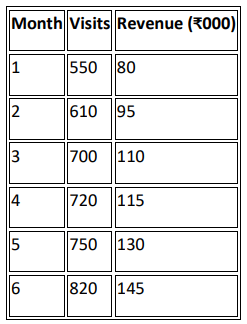

Tasks

1. Perform a univariate analysis on the visits column:

    o mean

    o std

    o plot line graph

2. Perform a bivariate analysis between visits and revenue.

3. Fit a simple linear regression to predict revenue from visits.

4. Predict revenue when visits = 780.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
# Import necessary scikit-learn modules for modeling
from sklearn.linear_model import LinearRegression

# Data Setup
# Note: Renaming 'Revenue (₹000)' to 'Revenue_k' for easier column access.
data = """
Month,Visits,Revenue_k
1,550,80
2,610,95
3,700,110
4,720,115
5,750,130
6,820,145
"""

# Load the dataset into a DataFrame
df = pd.read_csv(io.StringIO(data))

print("Dataset Head:")
print(df.head())

Dataset Head:
   Month  Visits  Revenue_k
0      1     550         80
1      2     610         95
2      3     700        110
3      4     720        115
4      5     750        130


1. Univariate Analysis (Visits) 

        Mean Visits:  691.67
 Standard Deviation:  97.45





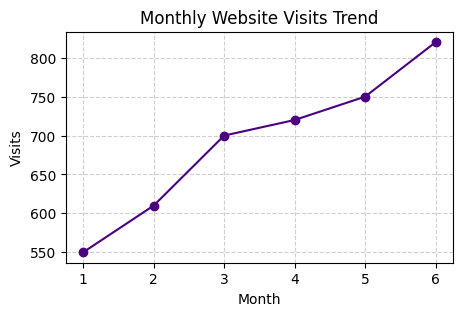

In [36]:
# 1. Perform a univariate analysis on the Visits column.
visits_series = df['Visits']

print("1. Univariate Analysis (Visits) \n")

# Compute Mean and Standard Deviation
mean_visits = visits_series.mean()
std_visits = visits_series.std()

print(f"        Mean Visits:  {mean_visits:.2f}")
print(f" Standard Deviation:  {std_visits:.2f}")
print("\n\n")

# Plot Line Graph
plt.figure(figsize=(5, 3))
plt.plot(df['Month'], visits_series, marker='o', linestyle='-', color='indigo')
plt.title('Monthly Website Visits Trend')
plt.xlabel('Month')
plt.ylabel('Visits')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2. Bivariate Analysis (Visits vs Revenue)

Correlation (Pearson R) between Visits and Revenue: 0.9889


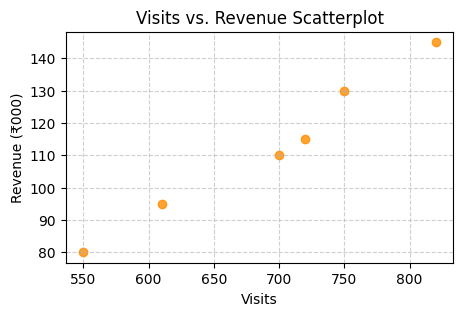


Interpretation:
The correlation is very close to 1.0, indicating a nearly perfect positive linear relationship: as visits increase, revenue consistently increases.


In [37]:

# 2. Perform a bivariate analysis between visits and revenue.
visits_revenue_corr = df['Visits'].corr(df['Revenue_k'])

print("2. Bivariate Analysis (Visits vs Revenue)\n")
print(f"Correlation (Pearson R) between Visits and Revenue: {visits_revenue_corr:.4f}")

plt.figure(figsize=(5, 3))
plt.scatter(df['Visits'], df['Revenue_k'], color='darkorange', alpha=0.8)
plt.title('Visits vs. Revenue Scatterplot')
plt.xlabel('Visits')
plt.ylabel('Revenue (₹000)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nInterpretation:")
print("The correlation is very close to 1.0, indicating a nearly perfect positive linear relationship: as visits increase, revenue consistently increases.")


In [38]:
# 3. Fit a simple linear regression to predict revenue from visits.
# Define X (feature) and y (target)
# Reshape X for scikit-learn (required for a single feature)
X = df['Visits'].values.reshape(-1, 1)
y = df['Revenue_k']

# Fit the model
model = LinearRegression()
model.fit(X, y)

print("\n3. Simple Linear Regression Model\n")
print(f"              Intercept (b0): {model.intercept_:.4f}")
print(f" Coefficient (b1 for Visits): {model.coef_[0]:.4f}")

# Regression Equation: Revenue = Intercept + Coefficient * Visits
print(f"\nModel Equation: Revenue (₹000) = {model.intercept_:.4f} + {model.coef_[0]:.4f} * Visits\n")



3. Simple Linear Regression Model

              Intercept (b0): -51.7375
 Coefficient (b1 for Visits): 0.2375

Model Equation: Revenue (₹000) = -51.7375 + 0.2375 * Visits



In [39]:
# 4. Predict revenue when visits = 780.
new_visits = np.array([[780]]) # Input must be in the same 2D format as X
predicted_revenue = model.predict(new_visits)

print("4. Prediction for 780 Visits \n")
print(f"Prediction Input (Visits): 780")
print(f" Predicted Revenue (₹000): {predicted_revenue[0]:.2f}")

# Convert to actual currency for better context
predicted_revenue_full = predicted_revenue[0] * 1000
print(f"        Predicted Revenue: ₹{predicted_revenue_full:,.2f}")

4. Prediction for 780 Visits 

Prediction Input: Visits = 780
Predicted Revenue (₹000): 133.47
Predicted Revenue: ₹133,474.90
